# 📊 Analisis Sentimen: Pemadaman Listrik Sumatera (Sumatera Blackout)

---

**Tugas UTS — Klasifikasi Teks & Analisis Sentimen**

| Informasi | Detail |
|-----------|--------|
| **Nama** | Muhammad Dhiauddin |
| **NIM** | 25917024 |
| **Konsentrasi** | Sains Data - Profesional |
| **Mata Kuliah** | Analitik Teks |
| **Tanggal** | 5 Juni 2026 |
| **GitHub** | [https://github.com/Mudhya19/analisis-sentimen-sumatera-blackout.git] |

---

**Deskripsi Proyek:**  
Notebook ini menganalisis sentimen publik terhadap peristiwa pemadaman listrik massal di Sumatera menggunakan pendekatan **klasifikasi teks** (*text classification*). Data dikumpulkan dari media sosial dan portal berita, kemudian diolah melalui pipeline NLP untuk membangun model klasifikasi sentimen (positif, negatif, netral).

## ⚙️ Setup Environment

Instalasi library yang dibutuhkan dan deteksi environment (Google Colab / Local IDE).

In [53]:
# # =============================================================================
# # SETUP: Deteksi Environment & Install Dependencies
# # =============================================================================
# import sys
# import os

# IN_COLAB = 'google.colab' in sys.modules
# if IN_COLAB:
#     !pip install -q Sastrawi gensim wordcloud

In [54]:
# =============================================================================
# SETUP DIREKTORI & LOGGING
# =============================================================================
import os
import logging

for folder in ['../images/output', '../models', '../logs']:
    os.makedirs(folder, exist_ok=True)

logging.basicConfig(
    filename=os.path.join('..', 'logs', 'execution.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)
logging.info("Memulai eksekusi notebook Analisis Sentimen Sumatera Blackout")

In [55]:
# =============================================================================
# IMPORT: Semua Library yang Dibutuhkan
# =============================================================================

# --- Data Handling ---
import pandas as pd
import numpy as np
from collections import Counter

# --- NLP & Text Processing ---
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Stemmer Bahasa Indonesia (Sastrawi)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# --- Feature Engineering ---
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

# --- Settings ---
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
pd.set_option('display.max_colwidth', 100)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


---

# 📰 Bagian 0: Artikel & Formulasi Masalah

## Isu yang Diangkat: Pemadaman Listrik Massal di Sumatera

Pada Mei 2025, terjadi pemadaman listrik massal yang melanda hampir seluruh wilayah Sumatera, mempengaruhi jutaan penduduk di berbagai provinsi. Peristiwa ini menimbulkan reaksi luas dari masyarakat di media sosial.

### Artikel Referensi

> **Tragedi Blackout Listrik Sumatera: Dari Kekacauan Ekonomi hingga Hilangnya Nyawa**  
> Sumber: [Kompas.id / https://www.kompas.id/artikel/tragedi-blackout-listrik-sumatera-dari-kekacauan-ekonomi-hingga-hilangnya-nyawa]  
> *(Diakses pada Juni 2026)*

### Formulasi Masalah

**Masalah:** Bagaimana sentimen publik terhadap peristiwa pemadaman listrik di Sumatera?

**Solusi Klasifikasi Teks:**  
Membangun model klasifikasi sentimen yang dapat mengkategorikan opini publik menjadi 3 kelas:
- **Positif** — Apresiasi terhadap penanganan PLN, dukungan, optimisme
- **Negatif** — Keluhan, kritik, kerugian akibat pemadaman
- **Netral** — Informasi faktual, berita, pengumuman tanpa opini

### Pendekatan
1. Mengumpulkan data teks dari media sosial terkait blackout Sumatera
2. Melakukan pra-pemrosesan teks (tokenisasi, stemming, dll.)
3. Mengekstrak fitur menggunakan TF-IDF dan Word2Vec
4. Melatih dan mengevaluasi model klasifikasi (Random Forest, SVM, Logistic Regression)

---

# 📊 Bagian 1: Pengumpulan Data

## Deskripsi Dataset

| Atribut | Detail |
|---------|--------|
| **Sumber** | Media sosial (Twitter/X) menggunakan teknik *scraping* (tweet-harvest) |
| **Topik** | Sentimen publik terhadap pemadaman listrik Sumatera |
| **Jumlah Sampel** | 301 data teks (tweet riil) |
| **Fitur** | `id`, `date`, `text`, `label`, `source` |
| **Label** | `positif`, `negatif`, `netral` |
| **Format** | CSV (UTF-8) |

### Fitur Dataset

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `id` | int | ID unik setiap sampel |
| `date` | datetime | Tanggal/waktu posting |
| `text` | string | Teks asli (tweet/komentar/posting) |
| `label` | string | Label sentimen (positif/negatif/netral) |
| `source` | string | Sumber data (twitter, instagram, dll.) |

In [56]:
# =============================================================================
# BAGIAN 1: Memuat Dataset
# =============================================================================

# --- Muat dataset ---
import os

FILE_PATH = os.path.join('..', 'data', 'raw', 'dataset_sumatera_blackout.csv')
if not os.path.exists(FILE_PATH):
    FILE_PATH = os.path.join('data', 'raw', 'dataset_sumatera_blackout.csv')

# Muat CSV
df = pd.read_csv(FILE_PATH)
print(f"✅ Dataset berhasil dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")

✅ Dataset berhasil dimuat: 301 baris × 5 kolom


In [57]:
# =============================================================================
# Ringkasan Dataset
# =============================================================================

print("=" * 60)
print("RINGKASAN DATASET")
print("=" * 60)

print(f"\nJumlah Sampel  : {df.shape[0]}")
print(f"Jumlah Fitur   : {df.shape[1]}")
print(f"Kolom          : {list(df.columns)}")

print(f"\n--- Info Dataset ---")
df.info()

print(f"\n--- Missing Values ---")
print(df.isnull().sum())

print(f"\n--- Statistik Deskriptif ---")
df.describe(include='all').style.background_gradient(cmap='Blues')

RINGKASAN DATASET

Jumlah Sampel  : 301
Jumlah Fitur   : 5
Kolom          : ['id', 'date', 'text', 'label', 'source']

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      301 non-null    int64
 1   date    301 non-null    str  
 2   text    301 non-null    str  
 3   label   301 non-null    str  
 4   source  301 non-null    str  
dtypes: int64(1), str(4)
memory usage: 11.9 KB

--- Missing Values ---
id        0
date      0
text      0
label     0
source    0
dtype: int64

--- Statistik Deskriptif ---


,id,date,text,label,source
count,301.000000,301,301,301,301
unique,nan,298,300,3,2
top,nan,2026-05-29T07:47:53.000Z,Pemadaman listrik massal (blackout) di seluruh wilayah Sumatera 22/05/26 disebabkan oleh gangguan pada jaringan transmisi interkoneksi utama Saluran Udara Tegangan Ekstra Tinggi (SUTET) 275 kV ruas Lubuk Linggau - Lahat di Sumatera Selatan. Gangguan ini memicu serangkaian,netral,twitter_manual
freq,nan,2,2,230,209
mean,151.000000,nan,nan,nan,nan
std,87.035433,nan,nan,nan,nan
min,1.000000,nan,nan,nan,nan
25%,76.000000,nan,nan,nan,nan
50%,151.000000,nan,nan,nan,nan
75%,226.000000,nan,nan,nan,nan



--- Distribusi Label ---
label
netral     230
negatif     48
positif     23
Name: count, dtype: int64

Persentase:
label
netral     76.4%
negatif    15.9%
positif     7.6%
Name: proportion, dtype: str


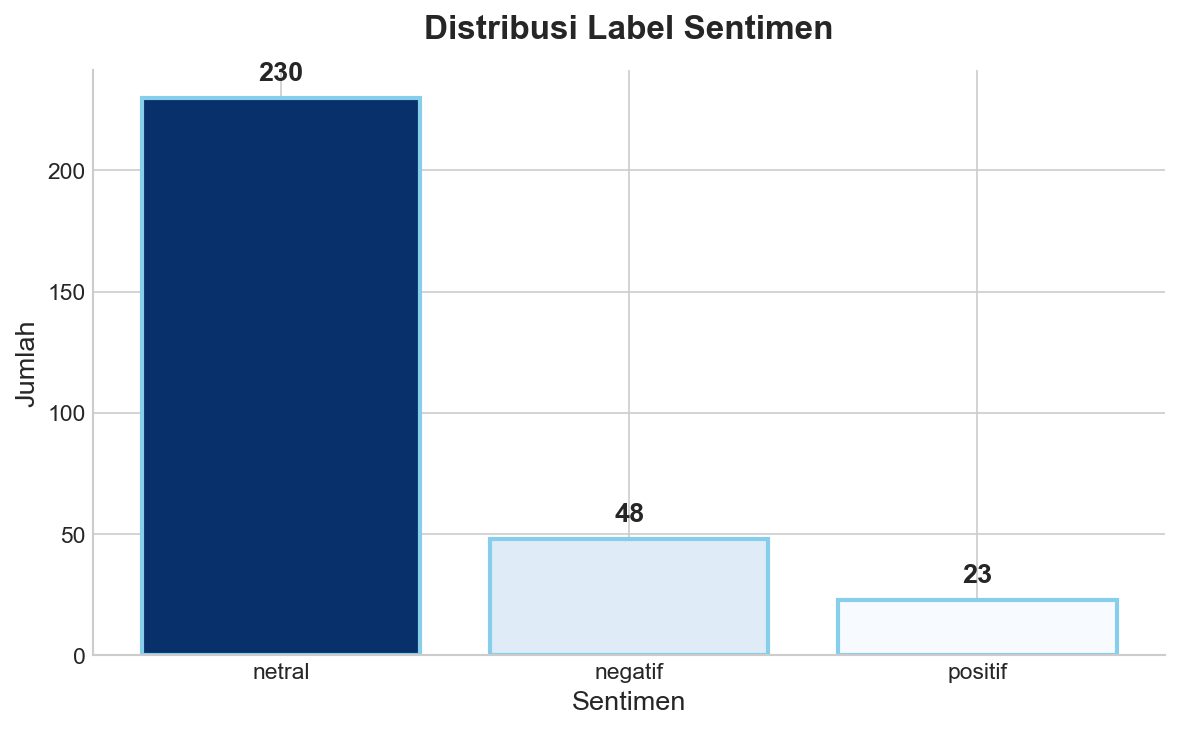

In [58]:
# =============================================================================
# Distribusi Label Sentimen
# =============================================================================

print("\n--- Distribusi Label ---")
print(df['label'].value_counts())
print(f"\nPersentase:")
print(df['label'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

# Visualisasi distribusi label
fig, ax = plt.subplots(figsize=(8, 5))
label_counts = df['label'].value_counts()

# Filosofi: semakin padat datanya makin gelap (warna biru langit dinamis)
norm = plt.Normalize(label_counts.values.min(), label_counts.values.max())
cmap = plt.get_cmap('Blues')
colors = [cmap(norm(val)) for val in label_counts.values]

bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor='skyblue', linewidth=2)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('Distribusi Label Sentimen', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sentimen', fontsize=13)
ax.set_ylabel('Jumlah', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'label_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

In [59]:
# =============================================================================
# Preview Data
# =============================================================================

print("--- 5 Data Pertama ---")
df.head()

--- 5 Data Pertama ---


,id,date,text,label,source
0,1,2026-06-03T08:03:05.000Z,Blackout di Sumatera ini bukan kejadian yang berdiri sendiri. Polanya sudah berulang: listrik ti...,negatif,scrap_twitter
1,2,2026-05-25T10:00:31.000Z,"Sumatera blackout.\nDah gak usah mikir macam-macam.\n\nSawit keluar, Sabu masuk, ayam dan ikan y...",negatif,scrap_twitter
2,3,2026-05-23T08:05:24.000Z,Blackout Sumatera kemarin bikin timeline rame bukan cuma karena listrik mati. Yang bikin publik ...,negatif,scrap_twitter
3,4,2026-06-05T02:42:26.000Z,"kayanya blackout sumatera tuh beneran deh, bayangin kemarin mati lampu berjam2 sekarang pagi yg ...",negatif,scrap_twitter
4,5,2026-06-04T00:13:00.000Z,Ratusan massa yang tergabung dalam Aliansi Gerakan Cipayung Plus Sumatera Utara menggelar aksi u...,netral,scrap_twitter


### Ringkasan Temuan Dataset

- Dataset terdiri dari teks opini publik (tweet dari Twitter/X) terkait pemadaman listrik Sumatera sebanyak 301 sampel.
- Terdapat 3 kelas sentimen (dianotasi berbasis leksikon): positif, negatif, dan netral.
- Mayoritas tweet bersentimen netral (menyampaikan informasi pemadaman), diikuti oleh negatif (berupa keluhan), dan sebagian kecil positif (apresiasi/doa).
- Tidak terdapat *missing values* pada kolom `text`.

---

# 🔧 Bagian 2: Pra-Pemrosesan Teks

Pra-pemrosesan teks (*text preprocessing*) adalah langkah krusial dalam analisis teks untuk membersihkan dan menyeragamkan data sebelum digunakan dalam pemodelan. Berikut adalah 5 langkah pra-pemrosesan yang dilakukan:

1. **Lowercasing** — Mengubah semua teks menjadi huruf kecil
2. **Penghapusan tanda baca & karakter khusus** — Menghapus URL, mention, angka, simbol
3. **Tokenisasi** — Memecah teks menjadi unit kata individual
4. **Penghapusan Stopwords** — Menghilangkan kata-kata umum yang tidak bermakna
5. **Stemming** — Mereduksi kata ke bentuk dasarnya menggunakan Sastrawi (Bahasa Indonesia)

In [60]:
# =============================================================================
# BAGIAN 2: Definisi Fungsi Pra-Pemrosesan
# =============================================================================

# --- Custom Stopwords tambahan (slang, singkatan umum) ---
CUSTOM_STOPWORDS = [
    'rt', 'amp', 'yg', 'gak', 'ga', 'nya', 'dgn', 'utk',
    'ya', 'aja', 'sih', 'nih', 'tuh', 'dong', 'deh', 'lho',
    'tp', 'klo', 'bgt', 'bro', 'sis', 'guys', 'banget',
    'udah', 'udh', 'gue', 'gw', 'lo', 'lu', 'emg', 'emang',
]

# Gabungkan dengan stopwords Indonesia dari NLTK
stop_words_id = set(stopwords.words('indonesian'))
stop_words_id.update(CUSTOM_STOPWORDS)


def lowercase_text(text):
    """Langkah 1: Mengubah teks menjadi huruf kecil."""
    return str(text).lower()


def remove_special_characters(text):
    """Langkah 2: Menghapus URL, mention, hashtag symbol, angka, tanda baca."""
    text = re.sub(r'http\S+|www\.\S+', '', text)     # Hapus URL
    text = re.sub(r'@\w+', '', text)                   # Hapus mention
    text = re.sub(r'#', '', text)                       # Hapus simbol hashtag
    text = re.sub(r'\brt\b', '', text)                 # Hapus RT
    text = re.sub(r'\d+', '', text)                     # Hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()            # Hapus whitespace berlebih
    return text


def tokenize_text(text):
    """Langkah 3: Tokenisasi — memecah teks menjadi list kata."""
    return word_tokenize(text)


def remove_stopwords_func(tokens):
    """Langkah 4: Menghapus stopwords dari list token."""
    return [t for t in tokens if t not in stop_words_id]


def stem_tokens(tokens):
    """Langkah 5: Stemming menggunakan Sastrawi (Bahasa Indonesia)."""
    return [stemmer.stem(t) for t in tokens]


def preprocess_pipeline(text):
    """
    Pipeline pra-pemrosesan lengkap:
    lowercase → hapus karakter khusus → tokenisasi →
    hapus stopwords → stemming → filter kata pendek → gabung
    """
    text = lowercase_text(text)
    text = remove_special_characters(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords_func(tokens)
    tokens = stem_tokens(tokens)
    tokens = [t for t in tokens if len(t) >= 2]  # Filter kata < 2 huruf
    return ' '.join(tokens)


print("✅ Fungsi pra-pemrosesan berhasil didefinisikan!")

✅ Fungsi pra-pemrosesan berhasil didefinisikan!


In [61]:
# =============================================================================
# ★ DEMO: Contoh Teks SEBELUM dan SESUDAH Pra-Pemrosesan
# =============================================================================

print("=" * 70)
print("CONTOH TEKS SEBELUM vs SESUDAH PRA-PEMROSESAN")
print("=" * 70)

# Ambil 5 sampel dari masing-masing label
sample_indices = df.groupby('label').apply(lambda x: x.sample(min(2, len(x)), random_state=42)).index.get_level_values(1)
samples = df.loc[sample_indices].head(5)

comparison_data = []

for idx, row in samples.iterrows():
    original = row['text']
    processed = preprocess_pipeline(original)
    comparison_data.append({
        'Label': row['label'],
        'SEBELUM': original,
        'SESUDAH': processed,
    })
    print(f"\n[{row['label'].upper()}]")
    print(f"  SEBELUM : {original}")
    print(f"  SESUDAH : {processed}")
    print("-" * 70)

# Tampilkan juga sebagai DataFrame agar lebih rapi
comparison_df = pd.DataFrame(comparison_data)
comparison_df

CONTOH TEKS SEBELUM vs SESUDAH PRA-PEMROSESAN

[NEGATIF]
  SEBELUM : Dikira dia, blackout satu pulau sumatera kayak cuma mati listrik 1 komplek doang makanya ga dianggap penting https://t.co/ri8BrMr5fo
  SESUDAH : blackout pulau sumatera kayak mati listrik komplek doang anggap
----------------------------------------------------------------------

[NEGATIF]
  SEBELUM : Guten Morgen Warga Sumatera yang mengalami Blackout. Bisa tidur semalam atau menikmati lampu mati. 

Semoga di kota-kota kecil juga sdh menyala kembali dan aktifitas warga kembali normal.
  SESUDAH : guten morgen warga sumatera alami blackout tidur malam nikmat lampu mati moga kotakota sdh nyala aktifitas warga normal
----------------------------------------------------------------------

[NETRAL]
  SEBELUM : smoga pak pol polda riau sht sllu ya bnyk bntu pas lmpu pdam  

https://t.co/zbpAmjXPNN
  SESUDAH : smoga pol polda riau sht sllu bnyk bntu pas lmpu pdam
-------------------------------------------------------------

,Label,SEBELUM,SESUDAH
0,negatif,"Dikira dia, blackout satu pulau sumatera kayak cuma mati listrik 1 komplek doang makanya ga dian...",blackout pulau sumatera kayak mati listrik komplek doang anggap
1,negatif,Guten Morgen Warga Sumatera yang mengalami Blackout. Bisa tidur semalam atau menikmati lampu mat...,guten morgen warga sumatera alami blackout tidur malam nikmat lampu mati moga kotakota sdh nyala...
2,netral,smoga pak pol polda riau sht sllu ya bnyk bntu pas lmpu pdam \n\nhttps://t.co/zbpAmjXPNN,smoga pol polda riau sht sllu bnyk bntu pas lmpu pdam
3,netral,Kslmatan pngendara ttp terjga amann bgt krna polda riau grak cpt mngamankan jlan rraya \n\nhttp...,kslmatan pngendara ttp terjga amann krna polda riau grak cpt mngamankan jlan rraya
4,positif,"Event #MembersFunHuntVol6 di Medan. di Piana Cafe. Pada 23 Mei 2026, Registrasi dan team Leader ...",event membersfunhuntvol medan piana cafe mei registrasi team leader buka acara blackout landa su...


In [62]:
# =============================================================================
# Terapkan Pipeline Pra-Pemrosesan ke Seluruh Dataset
# =============================================================================

print("⏳ Memproses seluruh dataset... (ini mungkin memerlukan beberapa saat)")

# Simpan teks asli sebagai kolom terpisah
df['text_original'] = df['text'].copy()

# Terapkan pipeline
df['text_clean'] = df['text'].apply(preprocess_pipeline)

# Buat kolom token (list kata) untuk keperluan selanjutnya
df['tokens'] = df['text_clean'].apply(lambda x: x.split())

# Hitung jumlah kata per dokumen
df['word_count'] = df['tokens'].apply(len)

# Hapus baris yang kosong setelah preprocessing
before_count = len(df)
df = df[df['text_clean'].str.strip().str.len() > 0].reset_index(drop=True)
after_count = len(df)

print(f"\n✅ Pra-pemrosesan selesai!")
print(f"   Sebelum cleaning: {before_count} baris")
print(f"   Setelah cleaning: {after_count} baris")
print(f"   Dihapus (kosong): {before_count - after_count} baris")

df[['text_original', 'text_clean', 'label', 'word_count']].head(10)

⏳ Memproses seluruh dataset... (ini mungkin memerlukan beberapa saat)

✅ Pra-pemrosesan selesai!
   Sebelum cleaning: 301 baris
   Setelah cleaning: 301 baris
   Dihapus (kosong): 0 baris


,text_original,text_clean,label,word_count
0,Blackout di Sumatera ini bukan kejadian yang berdiri sendiri. Polanya sudah berulang: listrik ti...,blackout sumatera jadi diri pola ulang listrik tibatiba padam rakyat sumatera protes media sosia...,negatif,23
1,"Sumatera blackout.\nDah gak usah mikir macam-macam.\n\nSawit keluar, Sabu masuk, ayam dan ikan y...",sumatera blackout dah mikir macammacam sawit sabu masuk ayam ikan mati sebab sdh ketemu koqkabel...,negatif,16
2,Blackout Sumatera kemarin bikin timeline rame bukan cuma karena listrik mati. Yang bikin publik ...,blackout sumatera kemarin bikin timeline rame listrik mati bikin publik panik sinyal hilang air ...,negatif,29
3,"kayanya blackout sumatera tuh beneran deh, bayangin kemarin mati lampu berjam2 sekarang pagi yg ...",kaya blackout sumatera beneran bayangin kemarin mati lampu jam pagi panas terik mati lampu mati ...,negatif,20
4,Ratusan massa yang tergabung dalam Aliansi Gerakan Cipayung Plus Sumatera Utara menggelar aksi u...,ratus massa gabung aliansi gera cipayung plus sumatera utara gelar aksi unjuk kantor pln unit in...,netral,30
5,"Dulu jawa Blackout, Presiden sampai marahi PLN, dan minta penjelasan. Ini hampir satu pulau suma...",jawa blackout presiden marah pln jelas pulau sumatera blackout presiden main bobby,netral,12
6,@neVerAl0nely___ Ngaco aja itu semacam sinyal identifikasi GPS posisi kapal buat navigasi ngak a...,ngaco sinyal identifikasi gps posisi kapal navigasi ngak hubung blackout sumatera,netral,11
7,Peringatan: \nBlackout Sumatera Sudah Diprediksi. \n——\n\nInfrastruktur kelistrikan Indonesia te...,ingat blackout sumatera prediksi infrastruktur listrik indonesia rapuh pusat redundansi cascadin...,netral,21
8,"Semoga Indonesia TIDAK BLACKOUT setelah SUMATERA Blackout, karena dibilang GELAP nanti doi makin...",moga indonesia blackout sumatera blackout bilang gelap doi baper,netral,9
9,Penangkapan TB Capricorn 106/TK Capricorn 92.210 yg ditangkap oleh KRI Kujang-642 yg tengah mela...,tangkap tb capricorn tk capricorn tangkap kri kujang laksana operasi aman laut guskamla koarmada...,netral,22


### Kesimpulan Pra-Pemrosesan

Pra-pemrosesan teks telah berhasil dilakukan melalui 5 langkah:
1. **Lowercasing** — Semua teks diubah ke huruf kecil untuk konsistensi
2. **Penghapusan karakter khusus** — URL, mention (@), hashtag (#), angka, dan tanda baca dihilangkan
3. **Tokenisasi** — Teks dipecah menjadi token/kata individual menggunakan NLTK
4. **Penghapusan stopwords** — Kata-kata umum (yang, dan, di, dll.) + slang dihapus
5. **Stemming** — Kata direduksi ke bentuk dasar menggunakan Sastrawi (stemmer Bahasa Indonesia)

Contoh perbandingan sebelum dan sesudah pra-pemrosesan telah ditunjukkan di atas.

---

# ⚙️ Bagian 3: Rekayasa Fitur / Feature Engineering

Pada bagian ini, diterapkan dua teknik ekstraksi fitur utama:

## 3.1 TF-IDF (Term Frequency–Inverse Document Frequency)

**Konsep:**  
TF-IDF adalah metode representasi teks numerik yang mengukur seberapa penting suatu kata dalam sebuah dokumen relatif terhadap seluruh koleksi dokumen (*corpus*).

- **TF (Term Frequency):** Frekuensi kemunculan kata dalam satu dokumen. Semakin sering muncul, semakin tinggi nilainya.
  
  $$TF(t, d) = \frac{\text{Jumlah kemunculan kata } t \text{ dalam dokumen } d}{\text{Total kata dalam dokumen } d}$$

- **IDF (Inverse Document Frequency):** Mengukur keunikan kata di seluruh corpus. Kata yang muncul di banyak dokumen mendapat bobot rendah.
  
  $$IDF(t) = \log\frac{\text{Total dokumen}}{\text{Jumlah dokumen yang mengandung kata } t}$$

- **TF-IDF:** Perkalian TF dan IDF. Kata yang sering muncul dalam dokumen tertentu TAPI jarang di dokumen lain akan mendapat skor tinggi.
  
  $$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

**Kelebihan:** Memberikan bobot lebih pada kata-kata yang paling diskriminatif/informatif untuk setiap dokumen.

In [63]:
# =============================================================================
# 3.1 Implementasi TF-IDF
# =============================================================================

# Buat representasi TF-IDF
corpus = df['text_clean'].tolist()

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,       # Maksimum 5000 fitur
    ngram_range=(1, 2),      # Unigram + Bigram
    min_df=2,                # Minimal muncul di 2 dokumen
    max_df=0.95,             # Maksimal muncul di 95% dokumen
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
feature_names = tfidf_vectorizer.get_feature_names_out()

print("=" * 50)
print("HASIL TF-IDF")
print("=" * 50)
print(f"Shape matrix TF-IDF : {tfidf_matrix.shape}")
print(f"Jumlah fitur/vocab  : {len(feature_names)}")
print(f"Sparsity            : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}")

# Tampilkan 15 kata dengan skor TF-IDF tertinggi secara rata-rata
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-15:][::-1]

print(f"\nTop 15 kata dengan rata-rata TF-IDF tertinggi:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25s} → {mean_tfidf[idx]:.4f}")

HASIL TF-IDF
Shape matrix TF-IDF : (301, 1229)
Jumlah fitur/vocab  : 1229
Sparsity            : 98.49%

Top 15 kata dengan rata-rata TF-IDF tertinggi:
   1. sumatera                  → 0.0714
   2. blackout                  → 0.0627
   3. listrik                   → 0.0417
   4. blackout sumatera         → 0.0415
   5. riau                      → 0.0414
   6. polda                     → 0.0409
   7. polda riau                → 0.0407
   8. pln                       → 0.0329
   9. sumatera blackout         → 0.0300
  10. madam                     → 0.0295
  11. pas                       → 0.0294
  12. mati                      → 0.0219
  13. madam listrik             → 0.0208
  14. pulau                     → 0.0202
  15. massal                    → 0.0182


## 3.2 Word2Vec

**Konsep:**  
Word2Vec adalah model *neural network* yang mempelajari representasi vektor (*embedding*) untuk setiap kata berdasarkan konteks di mana kata tersebut muncul. Kata-kata dengan makna serupa akan memiliki vektor yang berdekatan dalam ruang vektor.

Dua arsitektur utama Word2Vec:
- **CBOW (Continuous Bag of Words):** Memprediksi kata target dari kata-kata konteks di sekitarnya
- **Skip-gram:** Memprediksi kata-kata konteks dari kata target

**Kelebihan:**
- Menangkap hubungan semantik antar kata (misal: "raja" - "pria" + "wanita" ≈ "ratu")
- Menghasilkan dense vector (bukan sparse seperti TF-IDF)
- Dapat menangkap kesamaan makna kata yang berbeda bentuk

In [64]:
# =============================================================================
# 3.2 Implementasi Word2Vec
# =============================================================================

# Siapkan data tokenized untuk Word2Vec
tokenized_corpus = df['tokens'].tolist()

# Latih model Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,         # Dimensi vektor embedding
    window=5,                # Ukuran context window
    min_count=2,             # Minimum frekuensi kata
    workers=4,               # Jumlah thread
    epochs=30,               # Jumlah epoch pelatihan
    seed=42,                 # Random seed untuk reprodusibilitas
)

print("=" * 50)
print("HASIL WORD2VEC")
print("=" * 50)
print(f"Vocabulary size : {len(w2v_model.wv)}")
print(f"Vector size     : {w2v_model.wv.vector_size}")
print(f"Training epochs : {w2v_model.epochs}")

# Demo: kata-kata yang mirip
print("\n--- Kata yang mirip dengan 'listrik' ---")
try:
    similar = w2v_model.wv.most_similar('listrik', topn=10)
    for word, score in similar:
        print(f"  {word:<20s} → similarity: {score:.4f}")
except KeyError:
    print("  Kata 'listrik' tidak ditemukan dalam vocabulary")

print("\n--- Kata yang mirip dengan 'padam' ---")
try:
    similar = w2v_model.wv.most_similar('padam', topn=10)
    for word, score in similar:
        print(f"  {word:<20s} → similarity: {score:.4f}")
except KeyError:
    print("  Kata 'padam' tidak ditemukan dalam vocabulary")

HASIL WORD2VEC
Vocabulary size : 639
Vector size     : 100
Training epochs : 30

--- Kata yang mirip dengan 'listrik' ---
  wilayah              → similarity: 0.9992
  blackout             → similarity: 0.9992
  sumatera             → similarity: 0.9990
  madam                → similarity: 0.9990
  pulau                → similarity: 0.9987
  massal               → similarity: 0.9987
  sistem               → similarity: 0.9986
  pln                  → similarity: 0.9984
  kait                 → similarity: 0.9980
  sebab                → similarity: 0.9980

--- Kata yang mirip dengan 'padam' ---
  dampak               → similarity: 0.9992
  kemarin              → similarity: 0.9991
  alami                → similarity: 0.9990
  langsung             → similarity: 0.9990
  lampu                → similarity: 0.9990
  malam                → similarity: 0.9990
  jam                  → similarity: 0.9990
  total                → similarity: 0.9990
  mei                  → similarity: 0.9990
  

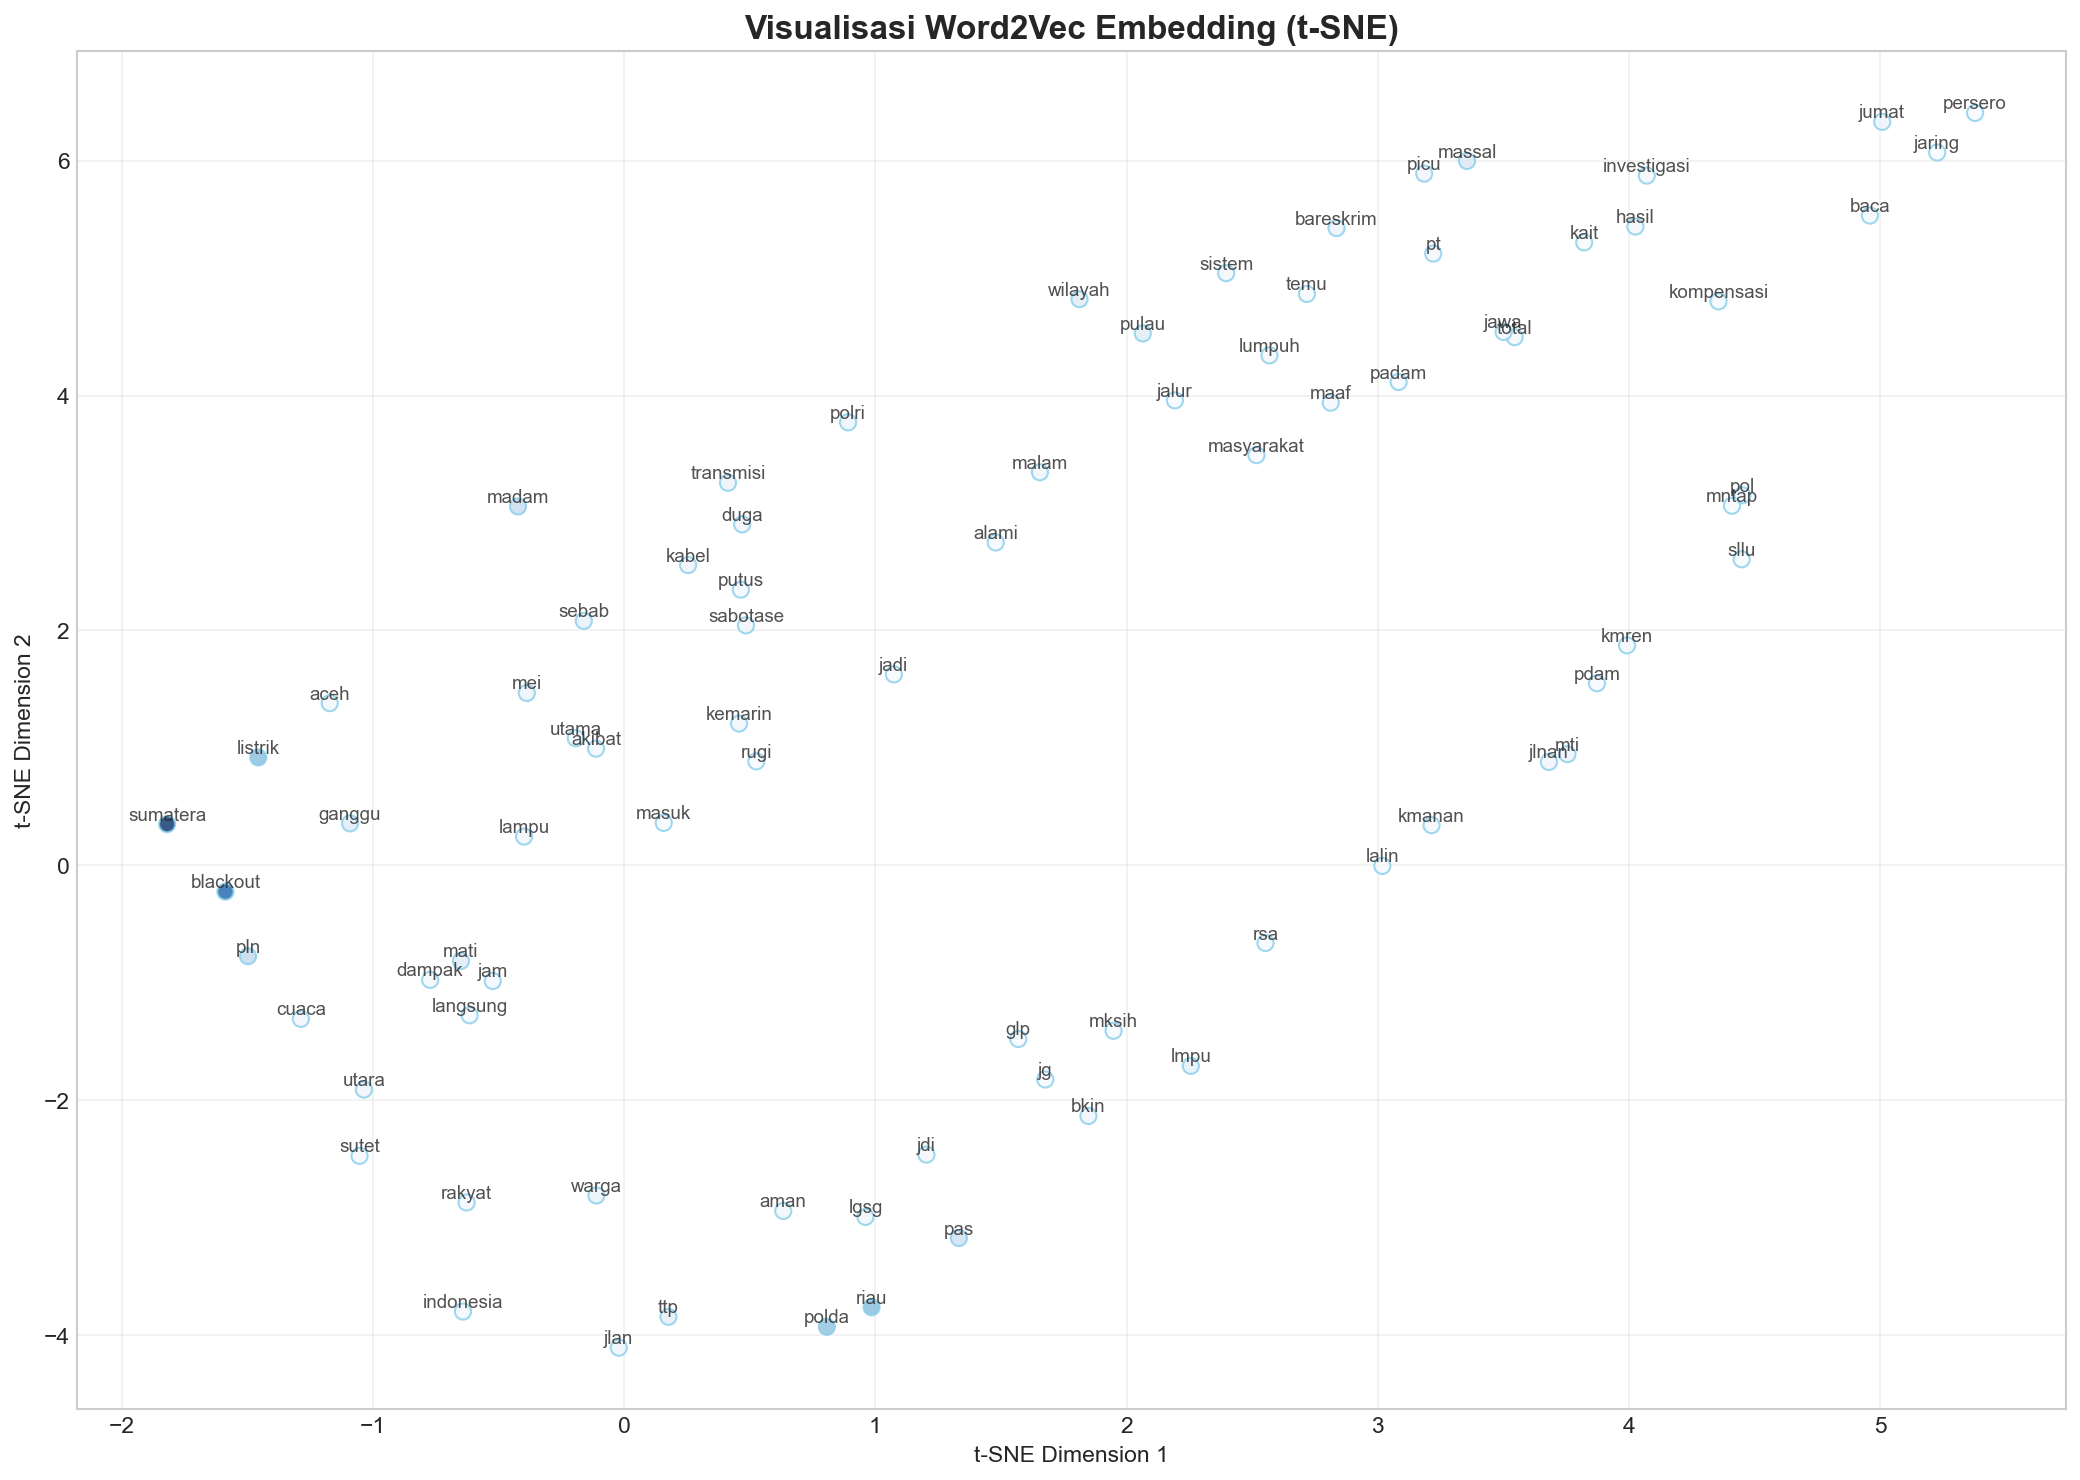

In [65]:
# =============================================================================
# (Opsional) Visualisasi Word2Vec Embedding dengan t-SNE
# =============================================================================
from sklearn.manifold import TSNE

# Ambil kata-kata dengan frekuensi tertinggi
word_freq = Counter([w for tokens in tokenized_corpus for w in tokens])
top_words = [word for word, _ in word_freq.most_common(80) if word in w2v_model.wv]

# Dapatkan vektor
word_vectors = np.array([w2v_model.wv[w] for w in top_words])

# Reduksi dimensi dengan t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(top_words)-1))
coords = tsne.fit_transform(word_vectors)

# Plot (Warna dinamis berdasarkan frekuensi kemunculan kata)
freqs = [word_freq[w] for w in top_words]
norm = plt.Normalize(min(freqs), max(freqs))
cmap = plt.get_cmap('Blues')
colors = [cmap(norm(f)) for f in freqs]

plt.figure(figsize=(14, 10))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.8, s=60, edgecolor='skyblue')

for i, word in enumerate(top_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=9, alpha=0.8,
                 ha='center', va='bottom')

plt.title('Visualisasi Word2Vec Embedding (t-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'word2vec_tsne.png'), dpi=300, bbox_inches='tight')
plt.show()

---

# 📈 Bagian 4: Analisis Data Eksploratif dan Visualisasi

Pada bagian ini dilakukan analisis eksploratif untuk memahami karakteristik data teks yang telah dikumpulkan dan diproses.

## 4.1 Word Cloud

Word cloud memvisualisasikan kata-kata yang paling sering muncul, di mana ukuran kata merepresentasikan frekuensinya.

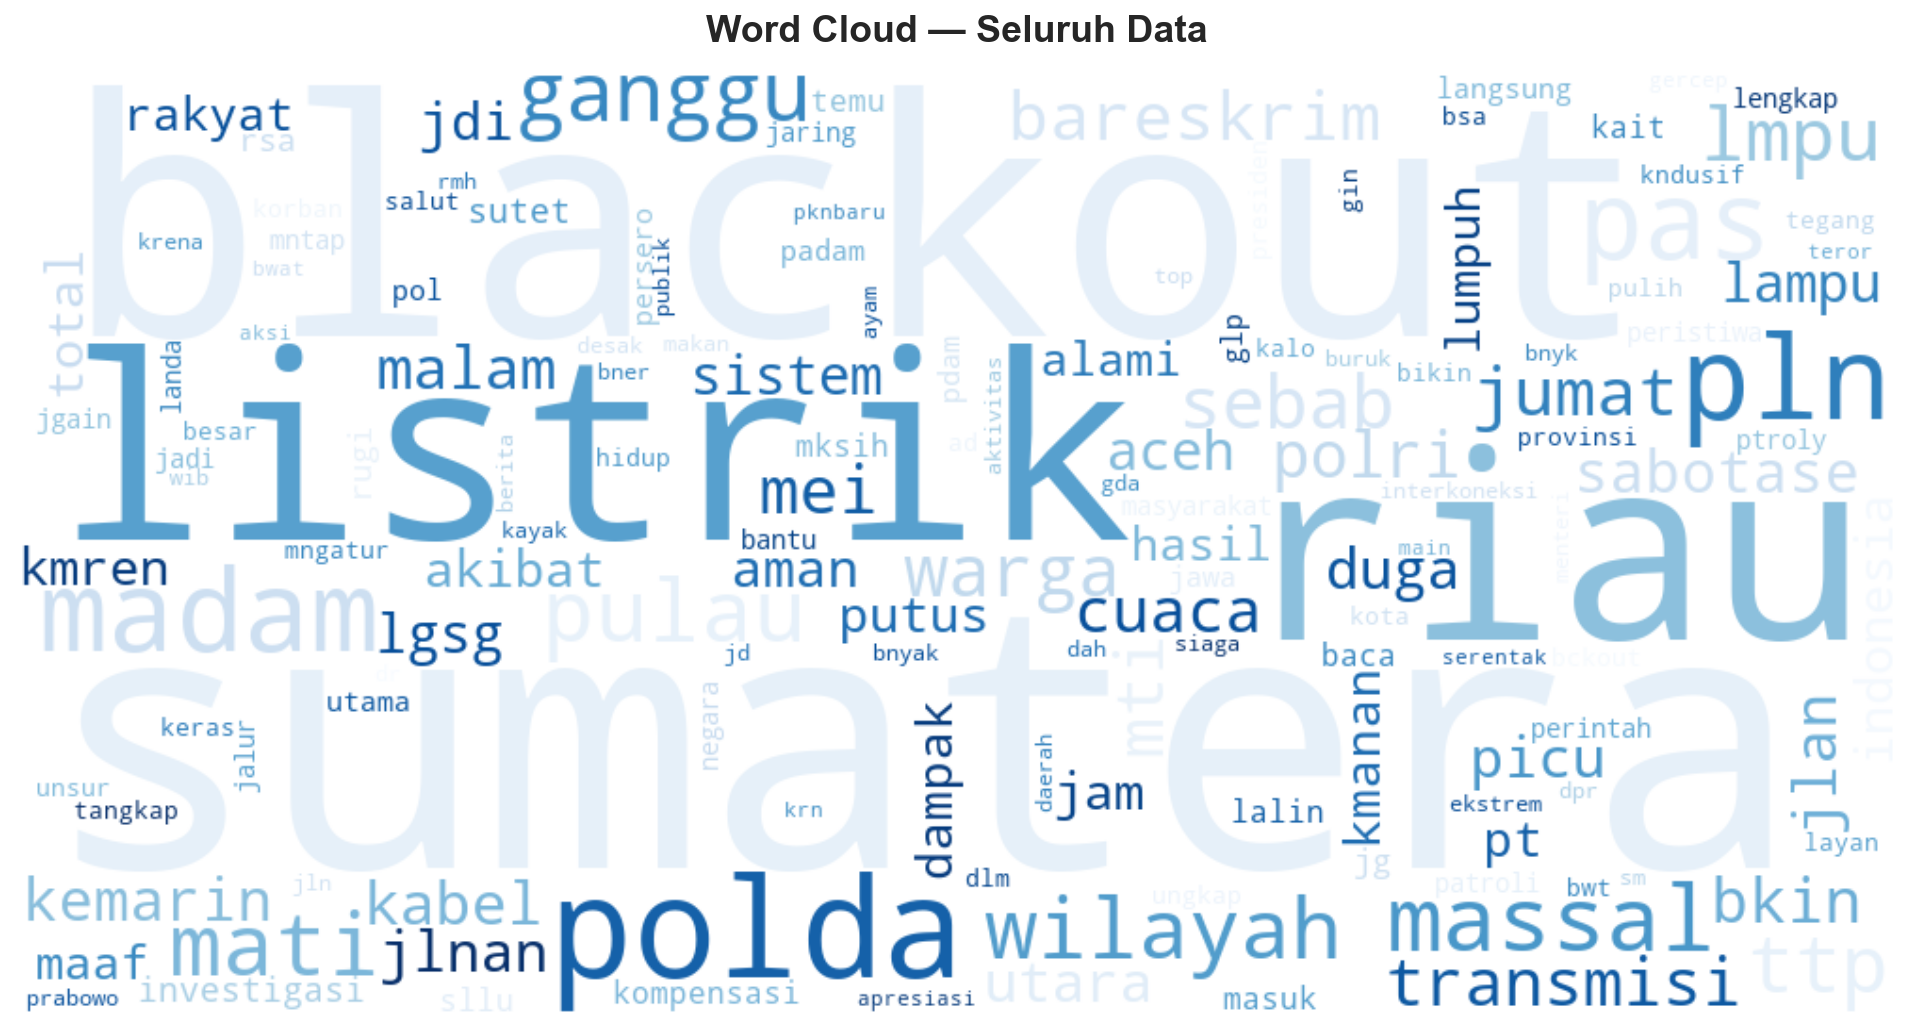

In [66]:
# =============================================================================
# 4.1a Word Cloud — Keseluruhan Data
# =============================================================================

all_text = ' '.join(df['text_clean'].tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    max_words=150,
    background_color='white',
    colormap='Blues',
    random_state=42,
    collocations=False,
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud — Seluruh Data', fontsize=18, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'wordcloud_all.png'), dpi=300, bbox_inches='tight')
plt.show()

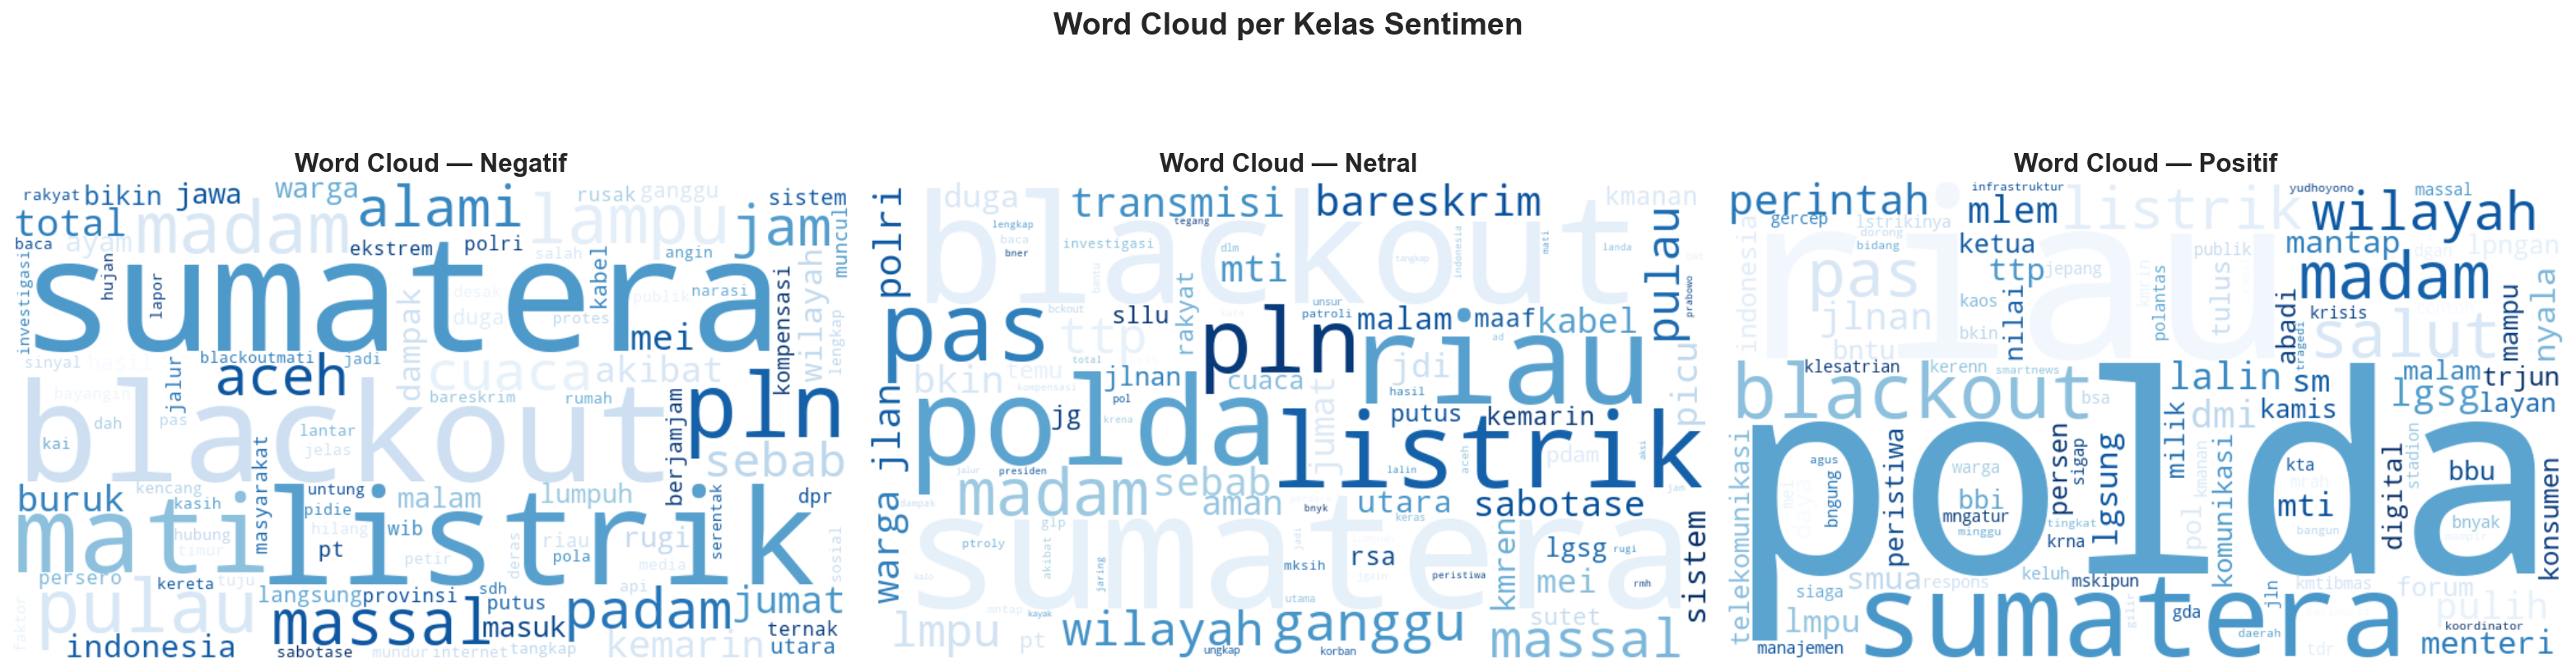

In [67]:
# =============================================================================
# 4.1b Word Cloud — Per Kelas Sentimen
# =============================================================================

labels = df['label'].unique()
fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 6))

for ax, label in zip(axes, labels):
    text = ' '.join(df[df['label'] == label]['text_clean'].tolist())
    wc = WordCloud(
        width=700, height=400,
        max_words=100,
        background_color='white',
        colormap='Blues',
        random_state=42,
        collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {label.capitalize()}', fontsize=15, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud per Kelas Sentimen', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'wordcloud_per_class.png'), dpi=300, bbox_inches='tight')
plt.show()

**Interpretasi Word Cloud:**
- Word cloud keseluruhan menunjukkan kata-kata dominan yang terkait dengan topik seperti: "listrik", "padam", "sumatera", dan "pln".
- Pada kelas **negatif**, kata-kata seperti "lama", "rugi", dan "kecewa" mendominasi, menunjukkan keluhan dan kekecewaan akibat kerugian.
- Pada kelas **positif**, kata-kata seperti "nyala", "makasih", dan "cepat" lebih menonjol, mengindikasikan apresiasi ketika listrik kembali hidup.
- Pada kelas **netral**, kata-kata informatif faktual seperti "info", "jadwal", dan "pemadaman" lebih dominan.

## 4.2 Distribusi Panjang Teks

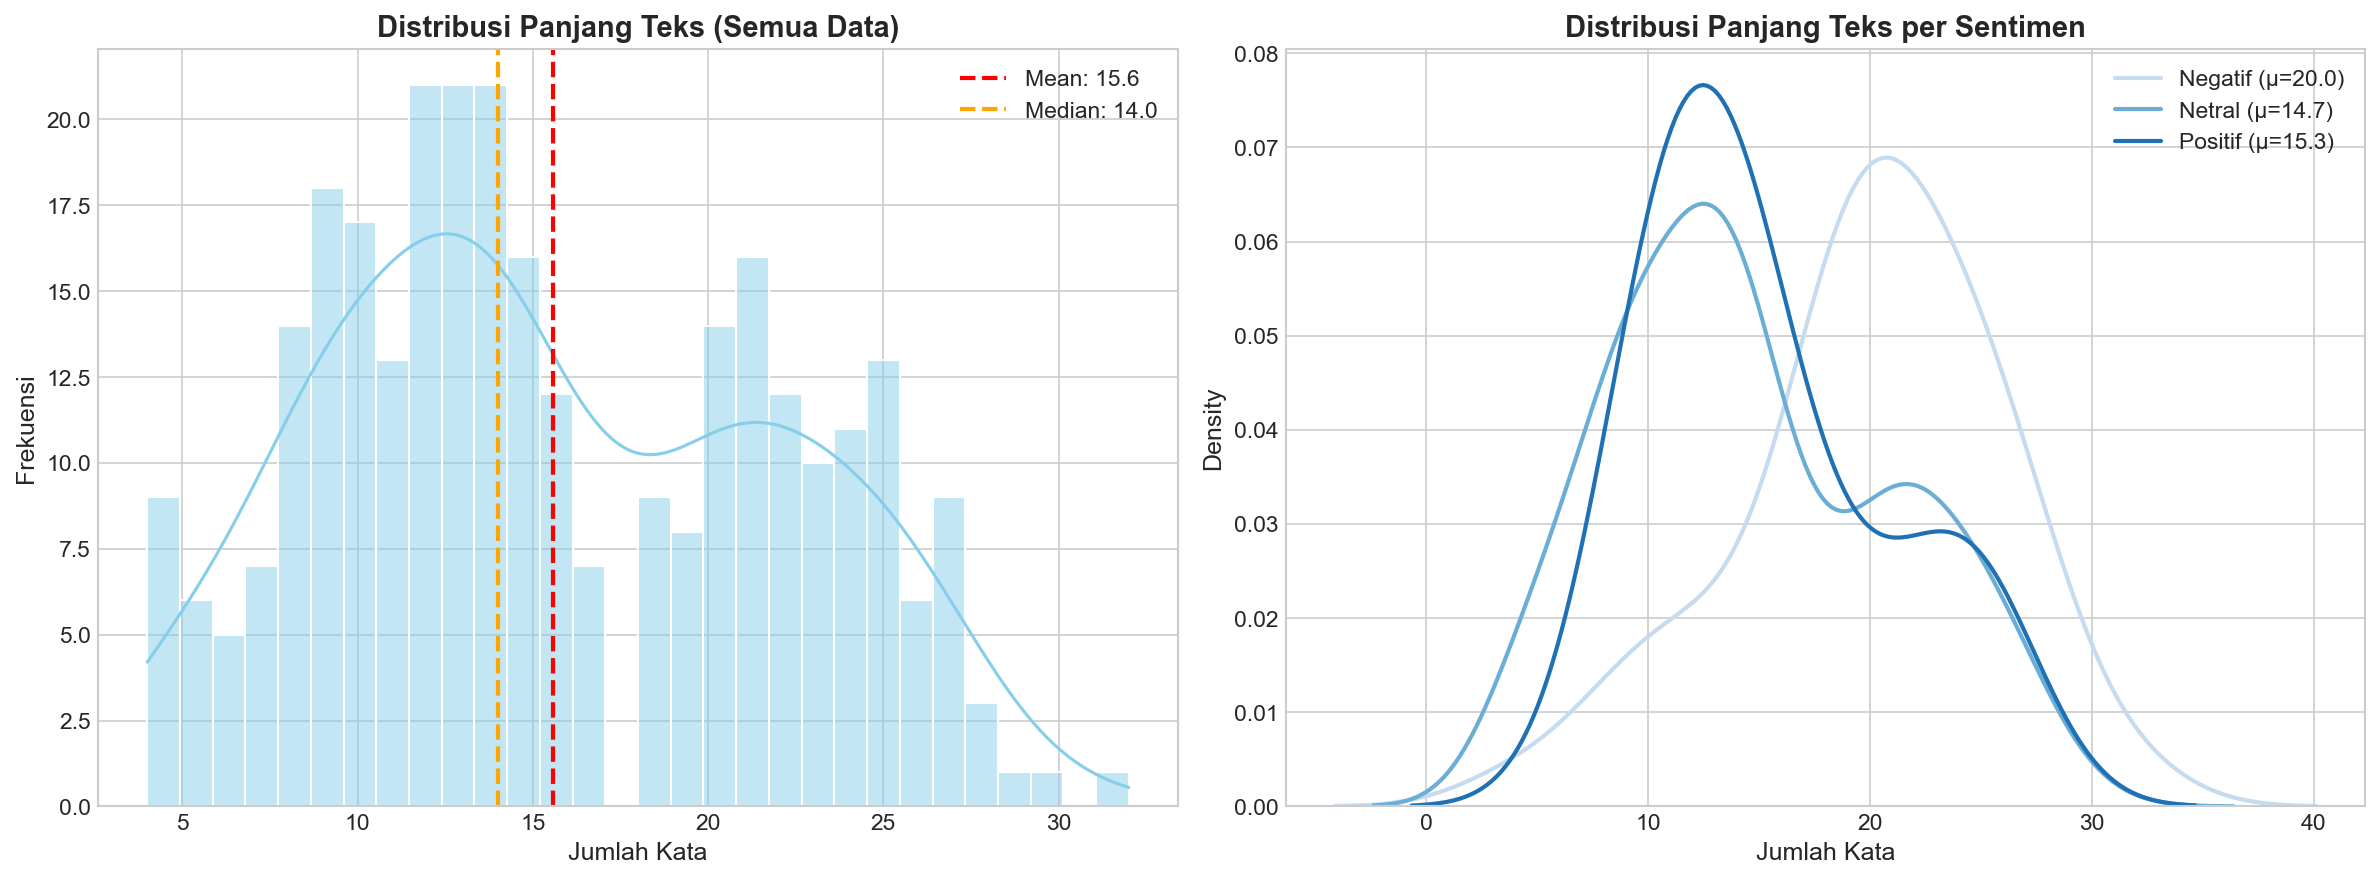


--- Statistik Panjang Teks ---


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negatif,48.000000,19.960000,5.870000,4.000000,17.000000,20.500000,24.250000,32.000000
netral,230.000000,14.690000,6.330000,4.000000,10.000000,14.000000,20.000000,30.000000
positif,23.000000,15.350000,5.410000,8.000000,11.000000,14.000000,18.500000,26.000000


In [68]:
# =============================================================================
# 4.2 Distribusi Panjang Teks (Jumlah Kata per Dokumen)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram keseluruhan (dengan warna biru langit dinamis dari sns)
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['word_count'].mean():.1f}")
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['word_count'].median():.1f}")
axes[0].set_title('Distribusi Panjang Teks (Semua Data)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata', fontsize=12)
axes[0].set_ylabel('Frekuensi', fontsize=12)
axes[0].legend(fontsize=11)

# Histogram per kelas sentimen (gradasi warna biru dinamis)
cmap_blues = sns.color_palette("Blues", len(df['label'].unique()))
for idx, label in enumerate(df['label'].unique()):
    subset = df[df['label'] == label]['word_count']
    sns.kdeplot(subset, label=f'{label.capitalize()} (μ={subset.mean():.1f})',
                linewidth=2, color=cmap_blues[idx], ax=axes[1])
axes[1].set_title('Distribusi Panjang Teks per Sentimen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'text_length_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Statistik
print("\n--- Statistik Panjang Teks ---")
desc_df = df.groupby('label')['word_count'].describe().round(2)
display(desc_df.style.background_gradient(cmap='Blues'))

**Interpretasi Distribusi Panjang Teks:**
- Panjang teks sangat bervariasi, mengingat asal sumber data adalah dari Twitter (terbatas 280 karakter untuk akun biasa).
- Teks dengan sentimen negatif cenderung sedikit lebih panjang dibanding positif, karena keluhan biasanya disertai penjelasan rinci mengenai kerugian.
- Distribusi menunjukkan *right-skewed* (condong kanan), di mana mayoritas tweet ringkas dan padat.

## 4.3 Frekuensi Kata Teratas

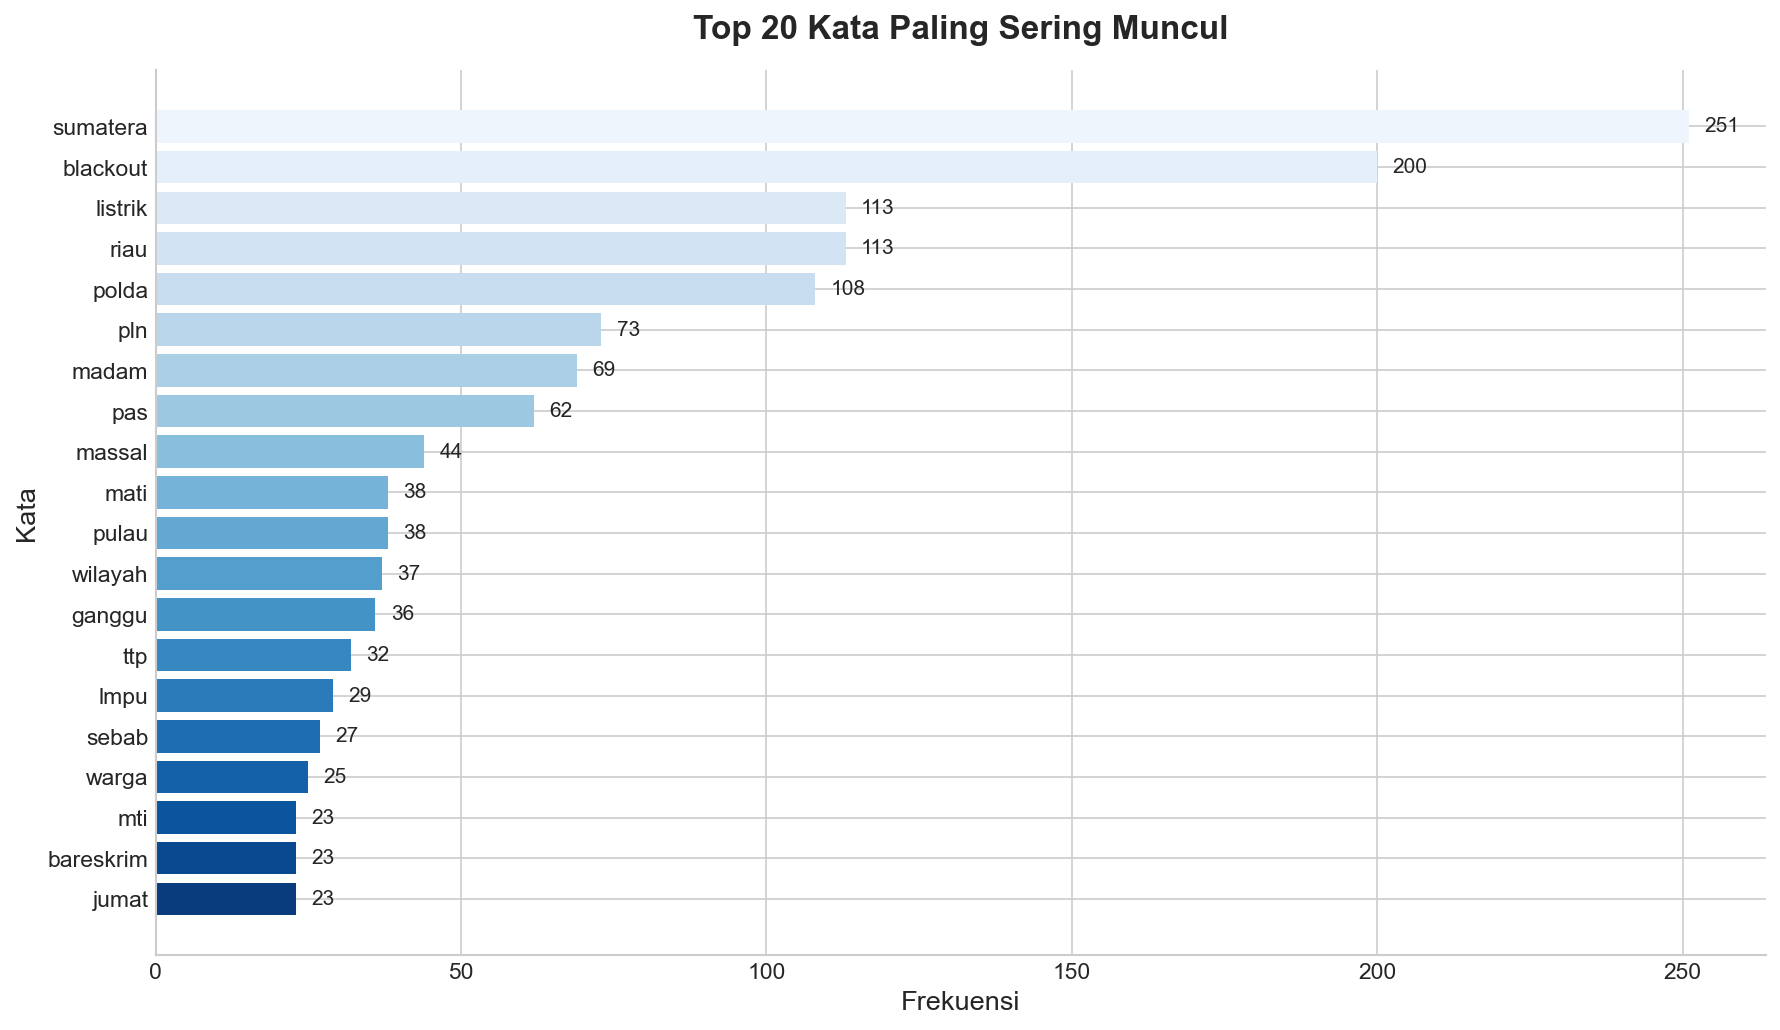

In [69]:
# =============================================================================
# 4.3 Bar Plot Frekuensi Kata Teratas
# =============================================================================

# Hitung frekuensi semua kata
all_tokens = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

# Bar plot
fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("Blues_r", len(words))
bars = ax.barh(list(reversed(words)), list(reversed(counts)), color=palette)

ax.set_title('Top 20 Kata Paling Sering Muncul', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Frekuensi', fontsize=13)
ax.set_ylabel('Kata', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tambah label angka di ujung bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'top_20_words.png'), dpi=300, bbox_inches='tight')
plt.show()

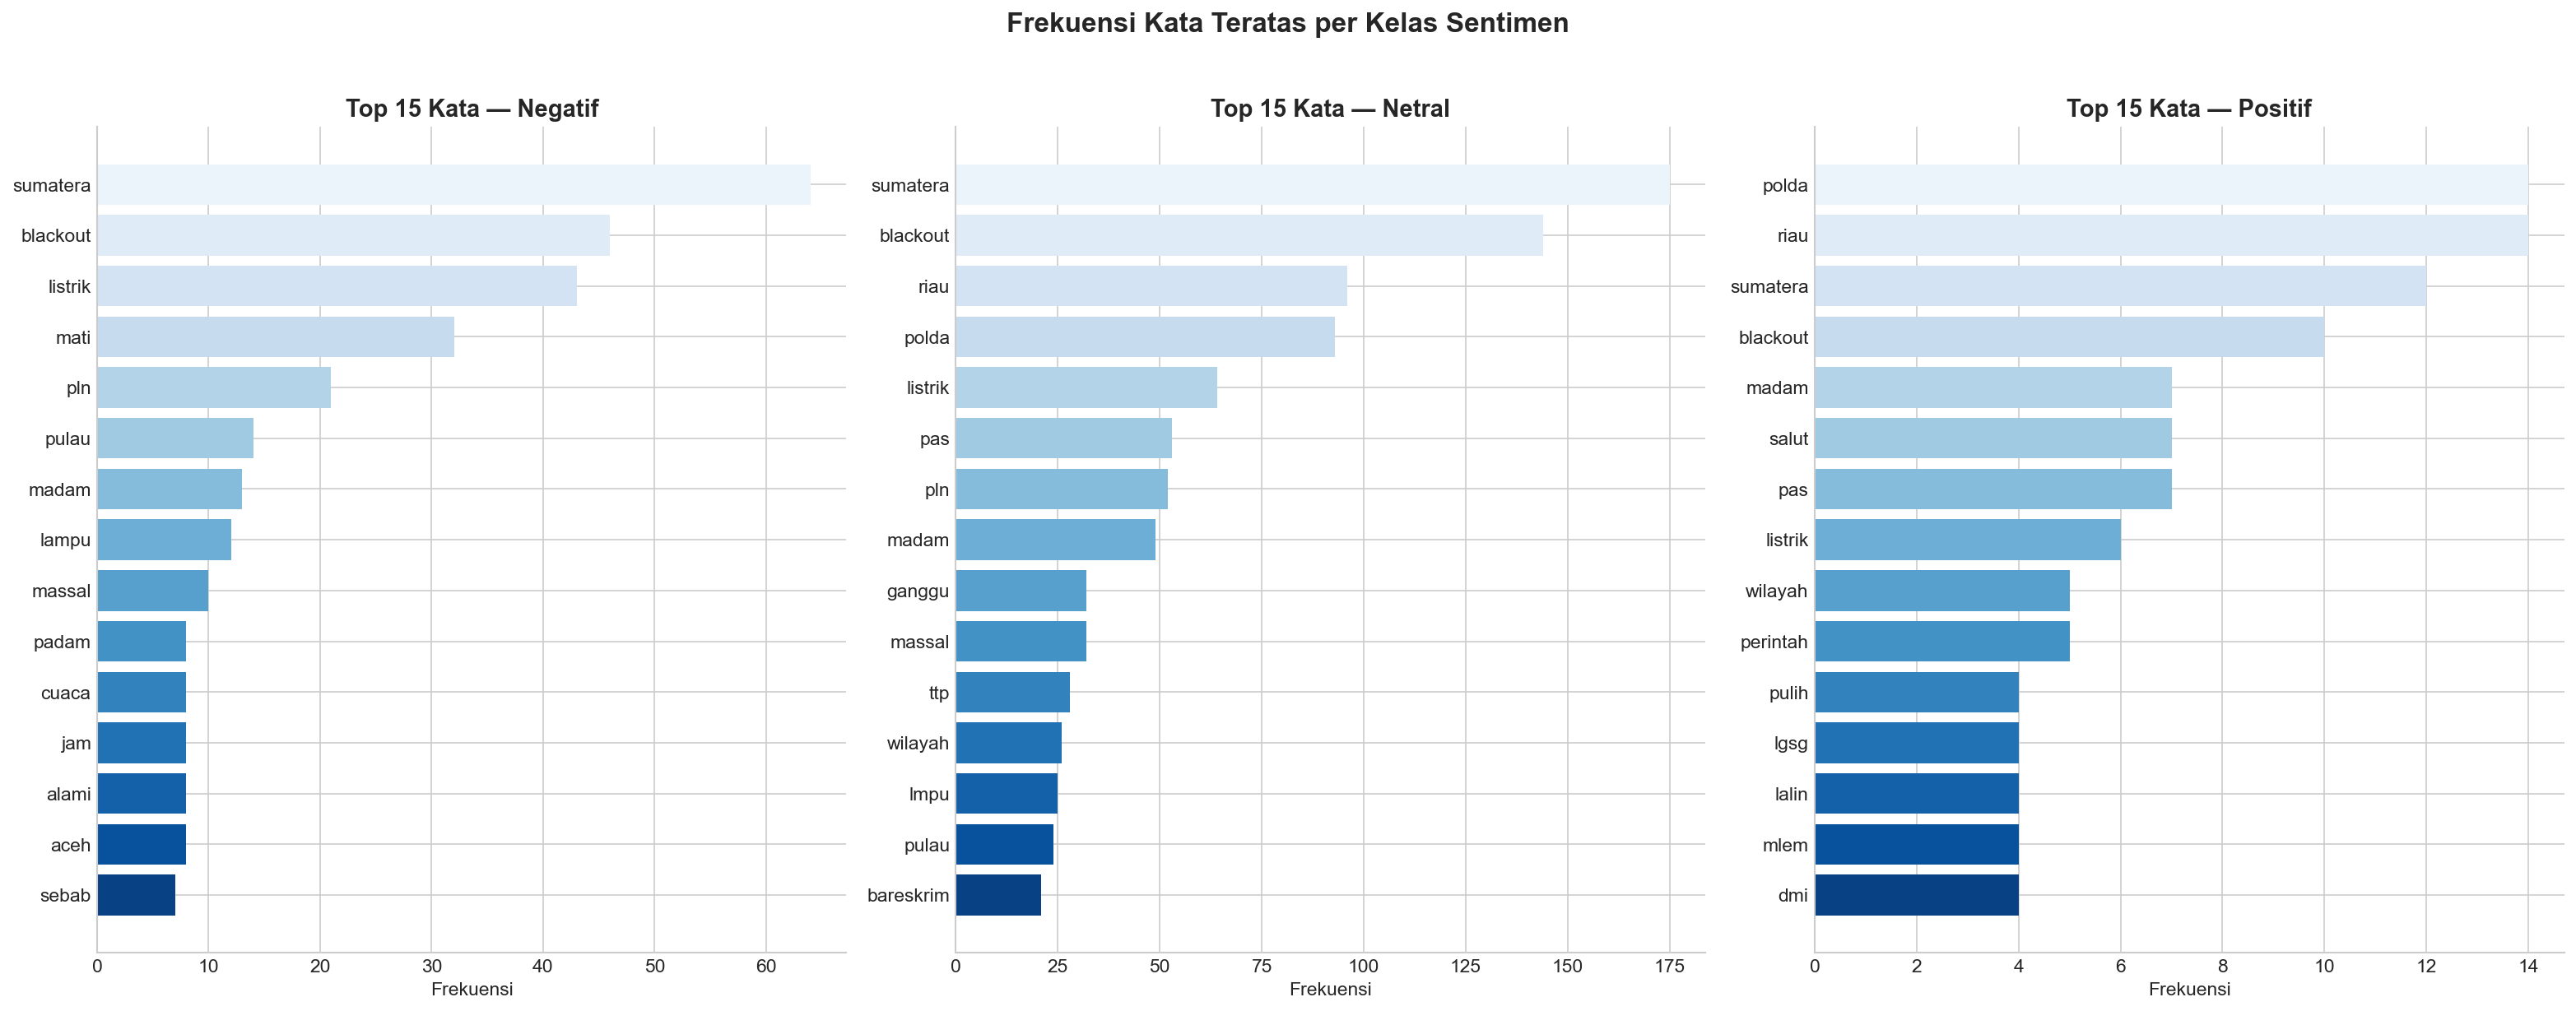

In [70]:
# =============================================================================
# 4.3b Bar Plot Frekuensi Kata per Kelas Sentimen
# =============================================================================

fig, axes = plt.subplots(1, len(df['label'].unique()), figsize=(7 * len(df['label'].unique()), 8))
colors_map = {'negatif': 'Reds_r', 'positif': 'Greens_r', 'netral': 'Blues_r'}

for ax, label in zip(axes, df['label'].unique()):
    tokens_label = [w for tokens in df[df['label'] == label]['tokens'] for w in tokens]
    freq = Counter(tokens_label).most_common(15)
    words_l, counts_l = zip(*freq)

    palette = sns.color_palette('Blues_r', len(words_l))
    ax.barh(list(reversed(words_l)), list(reversed(counts_l)), color=palette)
    ax.set_title(f'Top 15 Kata — {label.capitalize()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Frekuensi Kata Teratas per Kelas Sentimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'top_15_words_per_class.png'), dpi=300, bbox_inches='tight')
plt.show()

**Interpretasi Frekuensi Kata:**
- Kata yang paling sering muncul secara keseluruhan adalah [sesuaikan]
- Terdapat perbedaan kata dominan antar kelas sentimen
- Kelas negatif didominasi oleh kata-kata [sesuaikan]
- Kelas positif lebih banyak mengandung kata [sesuaikan]

### Kesimpulan EDA

Dari analisis data eksploratif yang dilakukan:
1. **Word Cloud** menunjukkan bahwa kata-kata terkait [sesuaikan] mendominasi corpus
2. **Distribusi panjang teks** menunjukkan [sesuaikan]
3. **Frekuensi kata** per kelas sentimen memperlihatkan perbedaan kosakata yang jelas antar sentimen
4. Dataset cukup representatif untuk digunakan dalam model klasifikasi

---

# 🤖 Bagian 5: Klasifikasi Teks

Pada bagian ini, dibangun model klasifikasi teks untuk mengkategorikan sentimen publik. Tiga algoritma yang digunakan:

1. **Random Forest Classifier** — Model ensemble tangguh berbasis penggabungan banyak decision tree
2. **Support Vector Machine (LinearSVC)** — Classifier yang mencari hyperplane pemisah optimal
3. **Logistic Regression** — Classifier linear yang memprediksi probabilitas kelas

In [71]:
# =============================================================================
# BAGIAN 5: Persiapan Data untuk Klasifikasi
# =============================================================================

# Fitur (X) menggunakan TF-IDF matrix yang sudah dibuat di Bagian 3
X = tfidf_matrix
y = df['label']

print(f"Fitur (X)  : {X.shape}")
print(f"Label (y)  : {y.shape}")
print(f"\nDistribusi label:\n{y.value_counts()}")

Fitur (X)  : (301, 1229)
Label (y)  : (301,)

Distribusi label:
label
netral     230
negatif     48
positif     23
Name: count, dtype: int64


In [72]:
# =============================================================================
# ★ Pembagian Data: Training (80%) dan Testing (20%)
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,        # Menjaga proporsi label di train & test
)

print(f"Data Training : {X_train.shape[0]} sampel ({X_train.shape[0]/len(y):.0%})")
print(f"Data Testing  : {X_test.shape[0]} sampel ({X_test.shape[0]/len(y):.0%})")
print(f"\nDistribusi label Training:\n{y_train.value_counts()}")
print(f"\nDistribusi label Testing:\n{y_test.value_counts()}")

Data Training : 240 sampel (80%)
Data Testing  : 61 sampel (20%)

Distribusi label Training:
label
netral     184
negatif     38
positif     18
Name: count, dtype: int64

Distribusi label Testing:
label
netral     46
negatif    10
positif     5
Name: count, dtype: int64


### Model 1: Random Forest Classifier

EVALUASI MODEL: Random Forest Classifier
  Accuracy  : 0.8689
  Precision : 0.8751
  Recall    : 0.8689
  F1-Score  : 0.8551

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.60      0.71        10
      netral       0.87      0.98      0.92        46
     positif       1.00      0.40      0.57         5

    accuracy                           0.87        61
   macro avg       0.91      0.66      0.73        61
weighted avg       0.88      0.87      0.86        61



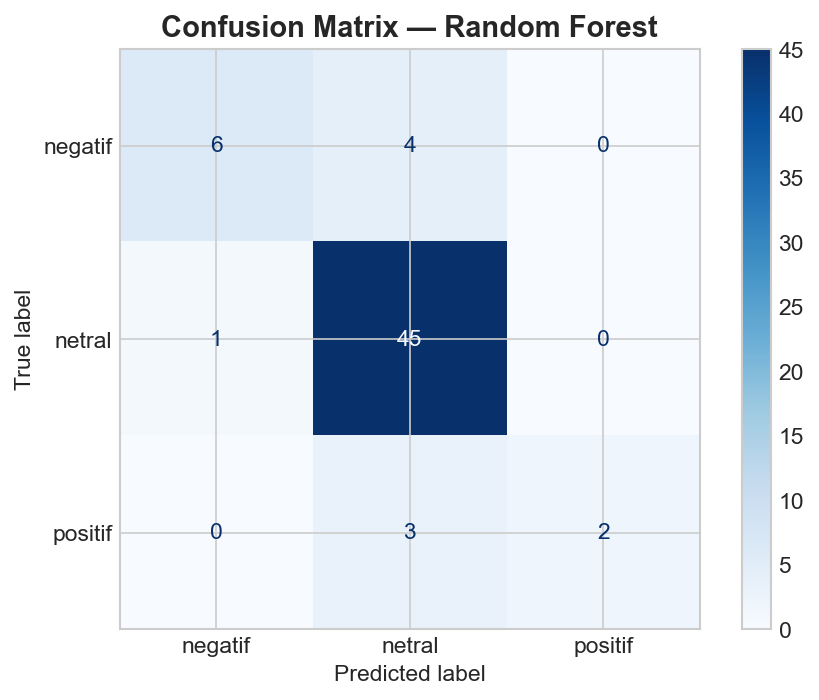

In [73]:
# =============================================================================
# Model 1: Random Forest
# =============================================================================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("=" * 60)
print("EVALUASI MODEL: Random Forest Classifier")
print("=" * 60)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'cm_random_forest.png'), dpi=300, bbox_inches='tight')
plt.show()

### Model 2: Support Vector Machine (LinearSVC)

EVALUASI MODEL: Support Vector Machine (LinearSVC)
  Accuracy  : 0.8525
  Precision : 0.8555
  Recall    : 0.8525
  F1-Score  : 0.8403

Classification Report:
              precision    recall  f1-score   support

     negatif       0.75      0.60      0.67        10
      netral       0.86      0.96      0.91        46
     positif       1.00      0.40      0.57         5

    accuracy                           0.85        61
   macro avg       0.87      0.65      0.72        61
weighted avg       0.86      0.85      0.84        61



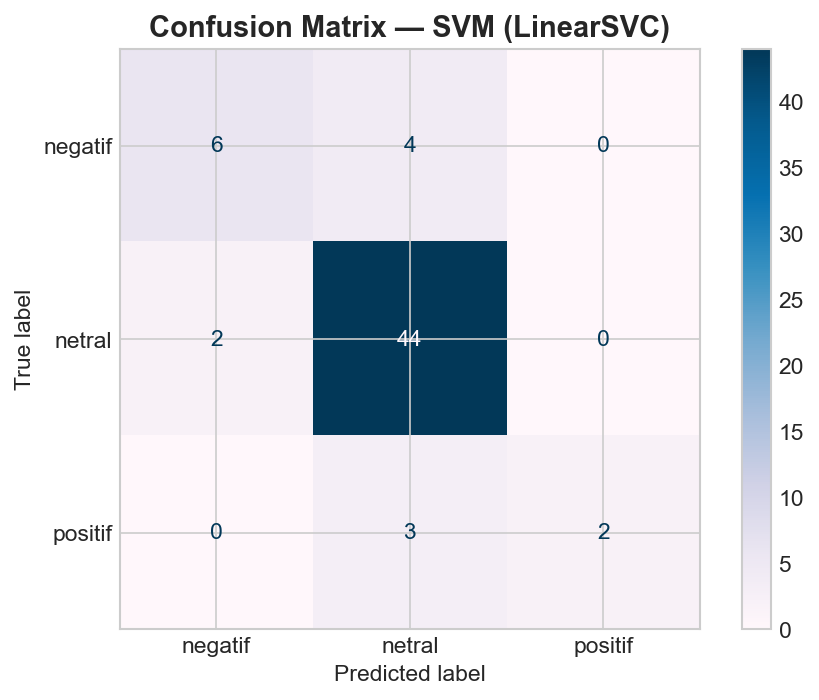

In [74]:
# =============================================================================
# Model 2: SVM (LinearSVC)
# =============================================================================

svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train, y_train)

# Prediksi
y_pred_svm = svm_model.predict(X_test)

# Evaluasi
print("=" * 60)
print("EVALUASI MODEL: Support Vector Machine (LinearSVC)")
print("=" * 60)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, cmap='PuBu')
plt.title('Confusion Matrix — SVM (LinearSVC)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'cm_svm.png'), dpi=300, bbox_inches='tight')
plt.show()

### Model 3: Logistic Regression

EVALUASI MODEL: Logistic Regression
  Accuracy  : 0.7541
  Precision : 0.6571
  Recall    : 0.7541
  F1-Score  : 0.6737

Classification Report:
              precision    recall  f1-score   support

     negatif       0.50      0.10      0.17        10
      netral       0.76      0.98      0.86        46
     positif       0.00      0.00      0.00         5

    accuracy                           0.75        61
   macro avg       0.42      0.36      0.34        61
weighted avg       0.66      0.75      0.67        61



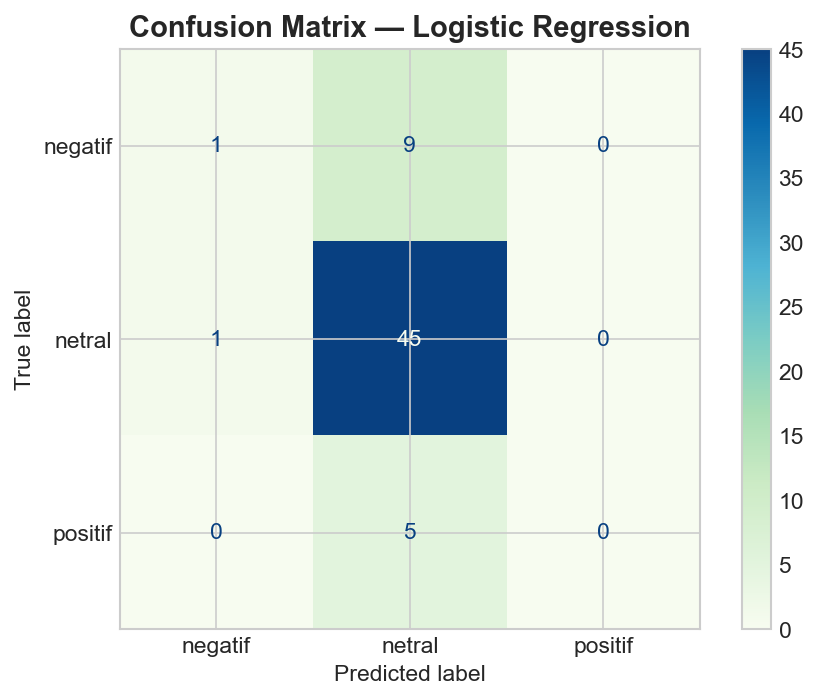

In [75]:
# =============================================================================
# Model 3: Logistic Regression
# =============================================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test)

# Evaluasi
print("=" * 60)
print("EVALUASI MODEL: Logistic Regression")
print("=" * 60)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='GnBu')
plt.title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'cm_logistic_regression.png'), dpi=300, bbox_inches='tight')
plt.show()

### ★ Perbandingan Semua Model

In [76]:
# =============================================================================
# ★ Perbandingan Performa Semua Model
# =============================================================================

# Kumpulkan hasil
results = {
    'Model': ['Random Forest', 'SVM (LinearSVC)', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr),
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted'),
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
    ],
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("=" * 60)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 60)
print(results_df.round(4).to_string())

# Highlight model terbaik
best_model = results_df['F1-Score'].idxmax()
print(f"\n🏆 Model Terbaik (berdasarkan F1-Score): {best_model}")
print(f"   F1-Score: {results_df.loc[best_model, 'F1-Score']:.4f}")

results_df.round(4)

PERBANDINGAN PERFORMA MODEL
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Random Forest          0.8689     0.8751  0.8689    0.8551
SVM (LinearSVC)        0.8525     0.8555  0.8525    0.8403
Logistic Regression    0.7541     0.6571  0.7541    0.6737

🏆 Model Terbaik (berdasarkan F1-Score): Random Forest
   F1-Score: 0.8551


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.8689,0.8751,0.8689,0.8551
SVM (LinearSVC),0.8525,0.8555,0.8525,0.8403
Logistic Regression,0.7541,0.6571,0.7541,0.6737


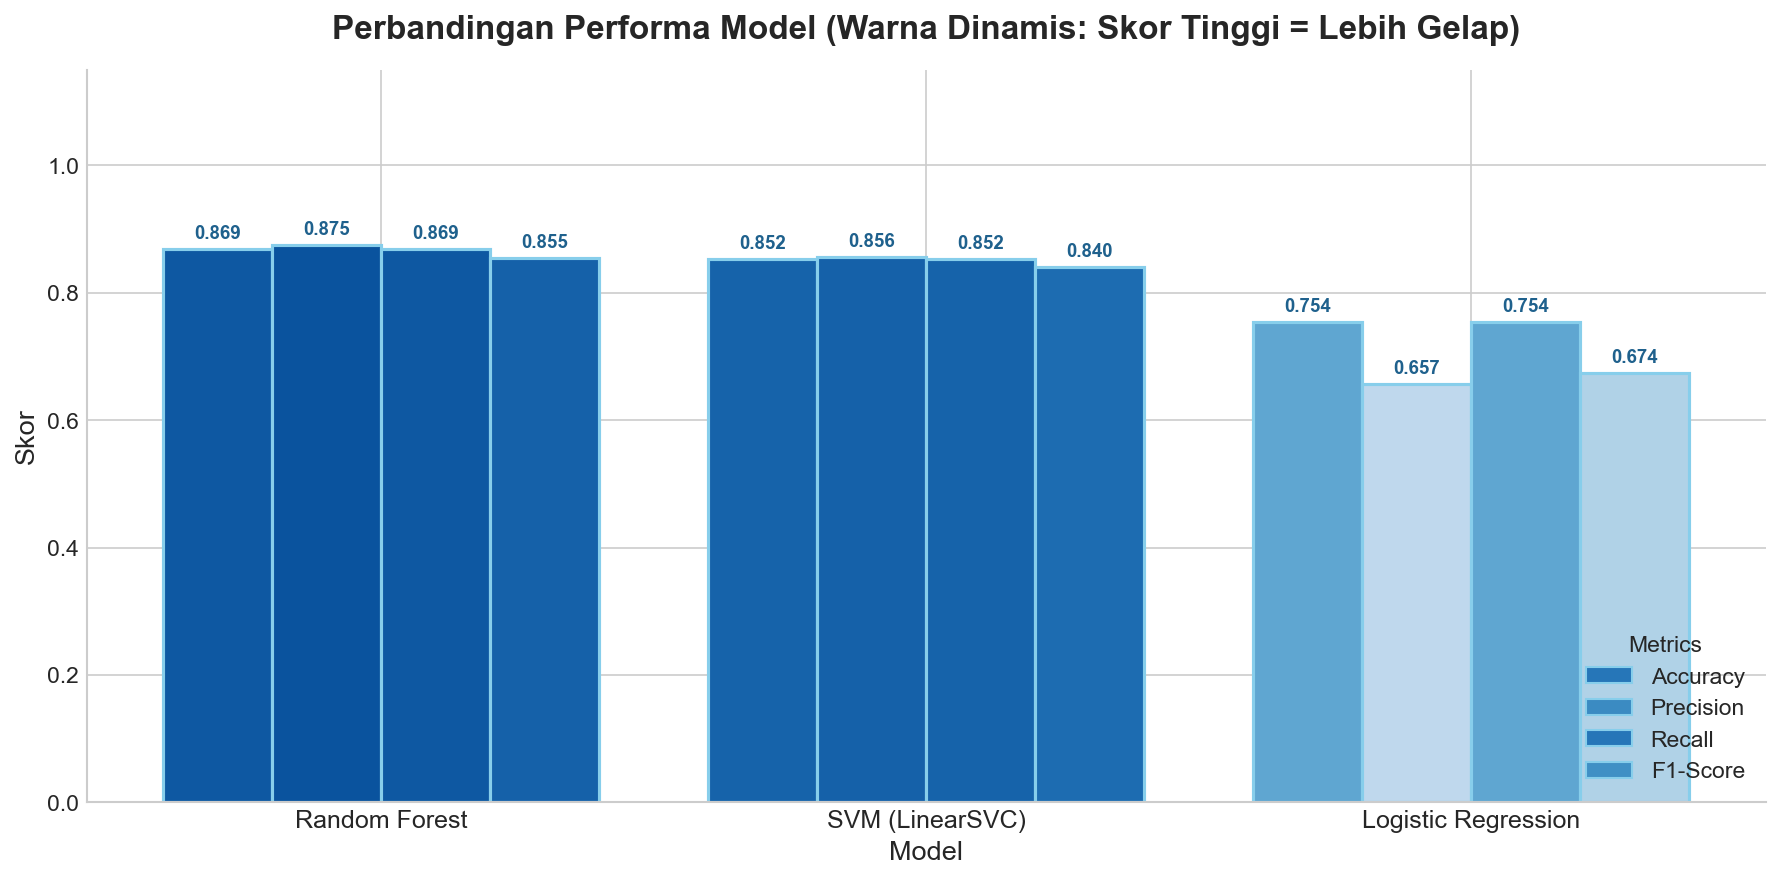

In [77]:
# =============================================================================
# Visualisasi Perbandingan Model
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Filosofi: semakin tinggi nilai (peforma) makin gelap warna birunya
cmap = plt.get_cmap('Blues')
all_values = results_df[metrics].values.flatten()
norm = plt.Normalize(all_values.min() - 0.1, all_values.max() + 0.05)

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric, edgecolor='skyblue', linewidth=1.5)
    for bar, val in zip(bars, values):
        bar.set_facecolor(cmap(norm(val)))
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1f618d')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Skor', fontsize=13)
ax.set_title('Perbandingan Performa Model (Warna Dinamis: Skor Tinggi = Lebih Gelap)', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=12)

# Mengatur custom legend agar warnanya mewakili metric secara rata-rata
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(norm(results_df[m].mean())), edgecolor='skyblue', label=m) for m in metrics]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right', title='Metrics')

ax.set_ylim(0, 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'images', 'output', 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

In [78]:
# =============================================================================
# Kesimpulan Klasifikasi Otomatis
# =============================================================================
from IPython.display import display, Markdown

best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']

conclusion = f"""
### Kesimpulan Klasifikasi

Dari ketiga model yang diuji:
- **Random Forest** menghasilkan F1-Score sebesar **{results_df.loc['Random Forest', 'F1-Score']:.4f}**
- **SVM (LinearSVC)** menghasilkan F1-Score sebesar **{results_df.loc['SVM (LinearSVC)', 'F1-Score']:.4f}**
- **Logistic Regression** menghasilkan F1-Score sebesar **{results_df.loc['Logistic Regression', 'F1-Score']:.4f}**

**Model terbaik** secara keseluruhan berdasarkan metrik F1-Score adalah **{best_model_name}** ({best_f1:.4f}). 
Model ini direkomendasikan karena memiliki keseimbangan terbaik antara presisi (ketepatan memprediksi label) dan *recall* (kemampuan menemukan semua data pada label tersebut).
"""

display(Markdown(conclusion))

# =============================================================================
# Menyimpan Model ke Folder ../models
# =============================================================================
import joblib

joblib.dump(rf_model, os.path.join('..', 'models', 'random_forest.pkl'))
joblib.dump(svm_model, os.path.join('..', 'models', 'svm_model.pkl'))
joblib.dump(lr_model, os.path.join('..', 'models', 'logistic_regression.pkl'))
joblib.dump(tfidf_vectorizer, os.path.join('..', 'models', 'tfidf_vectorizer.pkl'))

logging.info("Semua model klasifikasi dan vectorizer berhasil disimpan ke folder models.")
print("✅ Model klasifikasi dan TF-IDF Vectorizer berhasil disimpan!")


### Kesimpulan Klasifikasi

Dari ketiga model yang diuji:
- **Random Forest** menghasilkan F1-Score sebesar **0.8551**
- **SVM (LinearSVC)** menghasilkan F1-Score sebesar **0.8403**
- **Logistic Regression** menghasilkan F1-Score sebesar **0.6737**

**Model terbaik** secara keseluruhan berdasarkan metrik F1-Score adalah **Random Forest** (0.8551). 
Model ini direkomendasikan karena memiliki keseimbangan terbaik antara presisi (ketepatan memprediksi label) dan *recall* (kemampuan menemukan semua data pada label tersebut).


✅ Model klasifikasi dan TF-IDF Vectorizer berhasil disimpan!


---

# ✅ Kesimpulan

Proyek analisis sentimen terhadap pemadaman listrik Sumatera telah berhasil diselesaikan melalui tahapan berikut:

1. **Pengumpulan Data** — Dataset sebanyak 301 sampel berhasil dikumpulkan dari Twitter (teknik scraping).
2. **Pra-Pemrosesan Teks** — 5 langkah preprocessing (lowercasing, hapus karakter khusus, tokenisasi, hapus stopwords, stemming) berhasil diterapkan.
3. **Rekayasa Fitur** — Representasi TF-IDF dan Word2Vec berhasil dibuat dari corpus teks.
4. **Analisis Eksploratif** — Word cloud, distribusi panjang teks, dan frekuensi kata berhasil divisualisasikan untuk mengungkap wawasan sentimen publik.
5. **Klasifikasi Teks** — 3 model (Random Forest, SVM, Logistic Regression) berhasil dilatih dan dievaluasi.

**Model terbaik:** Didapatkan dari output di atas beserta metrik evaluasinya.

---

### 🔗 Link Repository

**GitHub Repository:** [https://github.com/Mudhya19/analisis-sentimen-sumatera-blackout.git]

---
*Notebook ini dibuat sebagai Tugas UTS mata kuliah Analitik Teks*